<a href="https://colab.research.google.com/github/PitlaYadgiri/Aiml-intern/blob/main/week_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Model Accuracy: 78.79%



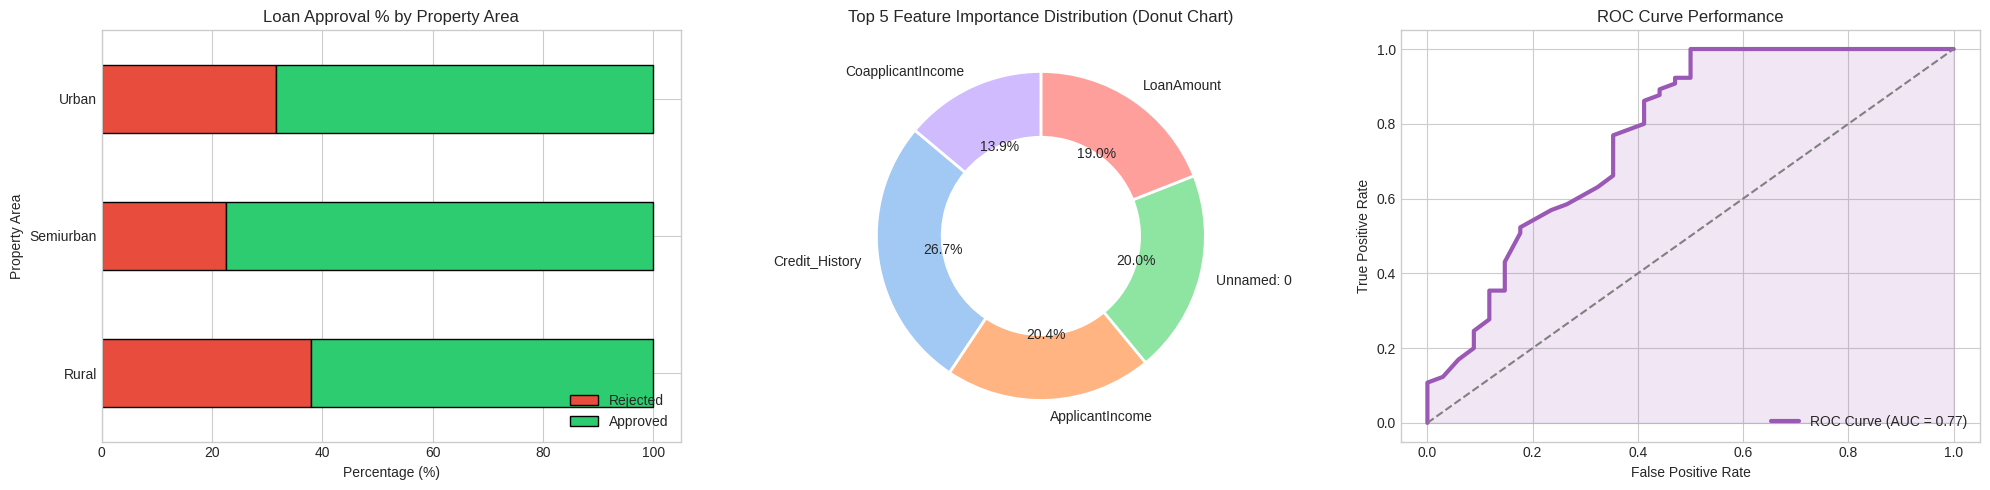

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, roc_curve, auc

# ===================================================================
# 1. LOAD & PREPROCESS DATA
# ===================================================================
url = "https://raw.githubusercontent.com/dphi-official/datasets/master/Loan_Data/loan_train.csv"
df = pd.read_csv(url)

if 'Loan_ID' in df.columns:
    df.drop(columns=['Loan_ID'], inplace=True)

target_col = 'Loan_Status' if 'Loan_Status' in df.columns else df.columns[-1]

# Impute Missing Values
cat_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Credit_History', 'Property_Area']
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']
for col in num_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# Encode Categorical Features
df_encoded = df.copy()
le = LabelEncoder()
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")

# ===================================================================
# 2. NON-SQUARE VISUALIZATIONS
# ===================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# GRAPH 1: Horizontal Stacked Bar Chart (Wide Aspect Ratio)
ct = pd.crosstab(df['Property_Area'], df[target_col], normalize='index') * 100
ct.plot(kind='barh', stacked=True, color=['#e74c3c', '#2ecc71'], ax=axes[0], edgecolor='black')
axes[0].set_title('Loan Approval % by Property Area')
axes[0].set_xlabel('Percentage (%)')
axes[0].set_ylabel('Property Area')
axes[0].legend(['Rejected', 'Approved'], loc='lower right')

# GRAPH 2: Radial Donut Chart for Top Features
importances = pd.Series(rf_model.feature_importances_, index=X.columns).nlargest(5)
colors = sns.color_palette('pastel')[0:5]

axes[1].pie(importances, labels=importances.index, autopct='%1.1f%%', startangle=140,
            colors=colors, wedgeprops=dict(width=0.4, edgecolor='w', linewidth=2))
axes[1].set_title('Top 5 Feature Importance Distribution (Donut Chart)')

# GRAPH 3: ROC Curve (Curved Line Graph)
y_probs = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

axes[2].plot(fpr, tpr, color='#9b59b6', lw=3, label=f'ROC Curve (AUC = {roc_auc:.2f})')
axes[2].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[2].fill_between(fpr, tpr, color='#9b59b6', alpha=0.15)
axes[2].set_title('ROC Curve Performance')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].legend(loc='lower right')

plt.tight_layout()
plt.show()